# Code to generate Figure 5 subplots

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from matplotlib.ticker import AutoMinorLocator
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

Remove proteins with low plddt, are membrane proteins and/or proteins predicted to be membrane proteins

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


## Figure 5A

* Create boxplots of protein half-lives for static and dynamic hubs in mass spec dataset

In [5]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=42):
    """
    Nonparametric bootstrap CI for the median
    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=np.float32)
    
    for b in trange(B, desc="Bootstrapping medians", leave=False):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)
    
    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

# Define MS degree hubs (top 10%)
ms_hubs = filtered_nodes[
    filtered_nodes['degree_centrality'] >= filtered_nodes['degree_centrality'].quantile(0.9)
].copy()

# Ensure boolean
ms_hubs['in_complex'] = ms_hubs['in_complex'].astype(bool)

# Split into Static (in complex) vs Dynamic (not in complex)
static_vals = ms_hubs[ms_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()
dynamic_vals = ms_hubs[~ms_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()

# NEW VARIABLE 
groups_step3 = [
    ("Static", static_vals, MS_COLOR_LIGHT),
    ("Dynamic", dynamic_vals, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:8}: n = {len(vals)}")

# Bootstrapped medians
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []
for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:8}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

# Mann-Whitney U test two-sided
u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='two-sided')
print("\n=== Mann–Whitney U test (Static vs Dynamic hubs) ===")
print(f"n(Static) = {len(static_vals)}, n(Dynamic) = {len(dynamic_vals)}")
print(f"median(Static) = {np.median(static_vals):.1f}, median(Dynamic) = {np.median(dynamic_vals):.1f}")
print(f"U = {u_stat:.1f}, p = {p_val:.2g}")
stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
print(f"Significance: {stars}")

# Mann-Whitney U test one-sided
u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='greater')
print("\n=== Mann–Whitney U test (Static vs Dynamic hubs) ===")
print(f"n(Static) = {len(static_vals)}, n(Dynamic) = {len(dynamic_vals)}")
print(f"median(Static) = {np.median(static_vals):.1f}, median(Dynamic) = {np.median(dynamic_vals):.1f}")
print(f"U = {u_stat:.1f}, p = {p_val:.2g}")
stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
print(f"Significance: {stars}")

=== Protein counts in Degree Hubs (MS) ===
Static  : n = 123
Dynamic : n = 101

=== Bootstrapped median half-life (95% CI) ===


Static  : median = 91.8 min, 95% CI = (88.8, 105.6)


Dynamic : median = 90.0 min, 95% CI = (89.4, 91.2)

=== Mann–Whitney U test (Static vs Dynamic hubs) ===
n(Static) = 123, n(Dynamic) = 101
median(Static) = 91.8, median(Dynamic) = 90.0
U = 7701.0, p = 0.002
Significance: **

=== Mann–Whitney U test (Static vs Dynamic hubs) ===
n(Static) = 123, n(Dynamic) = 101
median(Static) = 91.8, median(Dynamic) = 90.0
U = 7701.0, p = 0.001
Significance: **


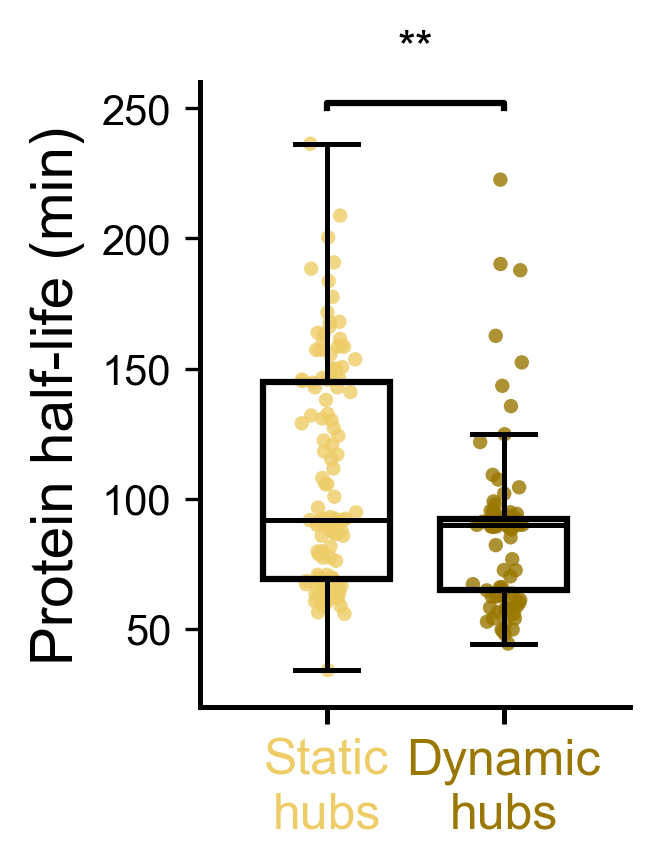

In [6]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 2   
    ax.plot([x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.5, 
            c="black",
            clip_on=False) 
    ax.text((x1 + x2)/2, 
            y_top * 1.05, 
            text,
            ha="center", 
            va="bottom", 
            fontsize=11,
           zorder=4)

# Prepare plot
fig, ax = plt.subplots(figsize=(2.3, 3))

positions = [1.0, 1.7]
group_data = [static_vals, dynamic_vals]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# Scatter (jittered)
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x_jitter, vals, s=12, color=color,
               alpha=0.8, edgecolor="none", zorder=2)

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_data,
    tick_labels=["Static\nhubs", "Dynamic\nhubs"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# === 3. X-axis labels ===
ax.set_xticks(positions)
ax.set_xticklabels(["Static\nhubs", "Dynamic\nhubs"],
                       fontsize=12)
ax.tick_params(axis="x", length=4, width=1.2)

labs = ax.get_xticklabels()
labs[0].set_color(MS_COLOR_LIGHT)
labs[1].set_color(MS_COLOR_DARK)

# Styling
#ax.set_yscale("log")
ax.set_ylim(20, 260)
#ax.minorticks_off()
ax.set_ylabel('Protein half-life (min)', fontsize=14)
ax.set_title("")

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 20
y_max = 260

# Significance bracket
add_bracket_with_text(ax, positions[0], positions[1], y=250, text=stars)

# Bottom group label: "AE-MS" style
#trans = ax.get_xaxis_transform()
#ax.plot([1.0, 1.7], [-0.26, -0.26], transform=trans, clip_on=False, color=MS_COLOR, lw=2.5)
#ax.text(1.4, -0.28, "AE-MS", transform=trans, ha="center", va="top",
#        fontsize=11, fontweight="bold", color=MS_COLOR)

plt.tight_layout()
plt.savefig("5.1.svg", dpi=400, bbox_inches='tight')
plt.show()

## Figure 5b
* Create boxplots of stability metrices and melting point for static and dynamic hubs in mass spec dataset

In [7]:
# === Prepare MS Degree Hubs (top 10%) ===
ms_hubs = filtered_nodes[
    filtered_nodes['degree_centrality'] >= filtered_nodes['degree_centrality'].quantile(0.9)
].copy()
ms_hubs['in_complex'] = ms_hubs['in_complex'].astype(bool)

# === Define the 4 stability metrics ===
stability_list = [
    ("Ghosh-Dill-dG",            "Ghosh-Dill ΔG"),
    ("cagiada-dG",               "Cagiada ΔG"),
    ("Rosetta_best_total_score", "Rosetta Total Score"),
    ("meltome-melting-point",    "Melting Point Tm (°C)"),
]

# === Extract clean values: Static vs Dynamic hubs ===
groups_step4 = []
for col, name in stability_list:
    if col == 'meltome-melting-point':
        data = ms_hubs[ms_hubs['meltome-fit-R2'] >= 0.9]   # High-quality meltome only
    else:
        data = ms_hubs
    
    static_vals  = data[data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    dynamic_vals = data[~data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    
    groups_step4.append((name, static_vals, dynamic_vals))

print("=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Degree Hubs ===\n")
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data")
        continue
    m_s, lo_s, hi_s = bootstrap_ci_median(static_vals, random_state=42)
    m_d, lo_d, hi_d = bootstrap_ci_median(dynamic_vals, random_state=42)
    print(f"{name:30} | Static:  {m_s:6.2f} [{lo_s:.1f}, {hi_s:.1f}]  (n={len(static_vals)})")
    print(f"{'':30} | Dynamic: {m_d:6.2f} [{lo_d:.1f}, {hi_d:.1f}]  (n={len(dynamic_vals)})\n")

=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Degree Hubs ===



Ghosh-Dill ΔG                  | Static:   -8.86 [-10.0, -8.3]  (n=134)
                               | Dynamic:  -7.65 [-8.1, -7.1]  (n=118)



Cagiada ΔG                     | Static:  -13.51 [-16.2, -11.7]  (n=134)
                               | Dynamic:  -9.97 [-11.5, -8.9]  (n=118)



Rosetta Total Score            | Static:  -760.02 [-910.1, -658.0]  (n=134)
                               | Dynamic: -565.20 [-688.3, -485.3]  (n=118)



Melting Point Tm (°C)          | Static:   46.74 [44.6, 48.0]  (n=82)
                               | Dynamic:  43.58 [42.9, 44.4]  (n=96)



In [8]:
print("\n=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===\n")

results = []
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data for test")
        results.append((name, np.nan, 1.0))
        continue
    
    u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='two-sided')
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    
    print(f"{name:30} | U = {u_stat:6.0f}, p = {p_val:.2g} {stars}")
    print(f"{'':32} Static median = {np.median(static_vals):.2f}, Dynamic = {np.median(dynamic_vals):.2f}\n")
    
    results.append((name, u_stat, p_val))

print("\n=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===\n")

results = []
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data for test")
        results.append((name, np.nan, 1.0))
        continue
    
    u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='greater')
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    
    print(f"{name:30} | U = {u_stat:6.0f}, p = {p_val:.2g} {stars}")
    print(f"{'':32} Static median = {np.median(static_vals):.2f}, Dynamic = {np.median(dynamic_vals):.2f}\n")
    
    results.append((name, u_stat, p_val))


=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===

Ghosh-Dill ΔG                  | U =   6167, p = 0.0026 **
                                 Static median = -8.86, Dynamic = -7.65

Cagiada ΔG                     | U =   6335, p = 0.0065 **
                                 Static median = -13.51, Dynamic = -9.97

Rosetta Total Score            | U =   6436, p = 0.011 *
                                 Static median = -760.02, Dynamic = -565.20

Melting Point Tm (°C)          | U =   5142, p = 0.00043 ***
                                 Static median = 46.74, Dynamic = 43.58


=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===

Ghosh-Dill ΔG                  | U =   6167, p = 1 N.S.
                                 Static median = -8.86, Dynamic = -7.65

Cagiada ΔG                     | U =   6335, p = 1 N.S.
                                 Static median = -13.51, Dynamic = -9.97

Rosetta Total Score            | U =   6436, p = 0.99 N.S.
                 

/tmp/ipykernel_1622/1352574327.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: 5.2.svg


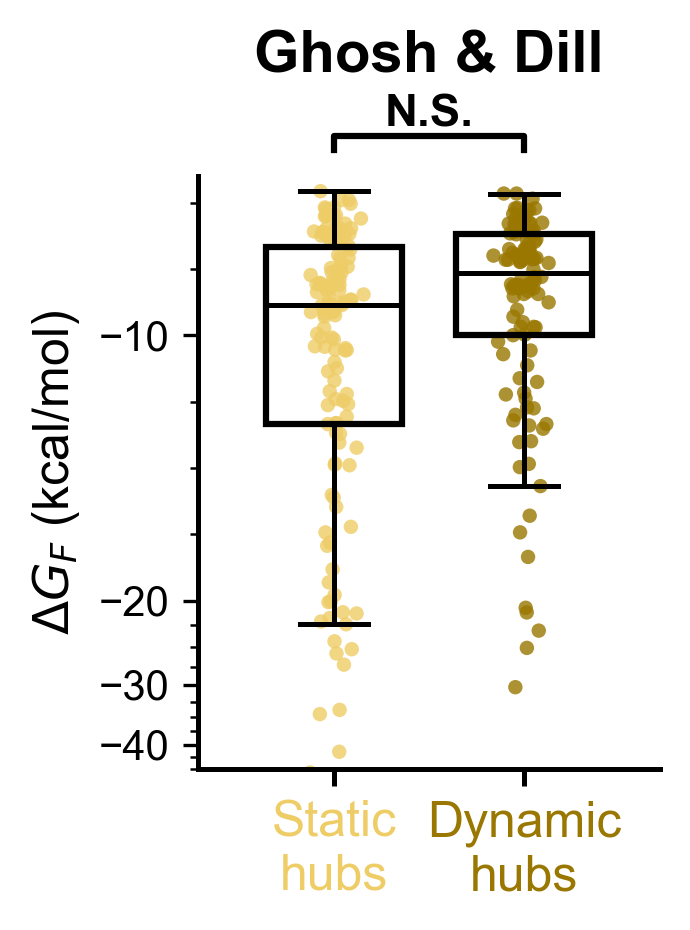

/tmp/ipykernel_1622/1352574327.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: 5.3.svg


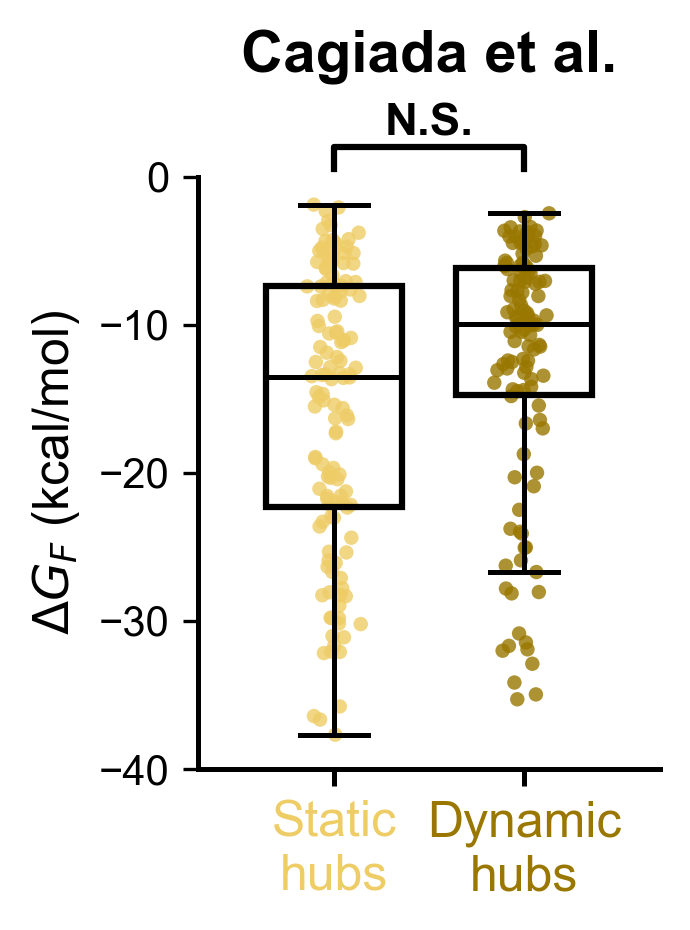

Saved: 5.4.svg


/tmp/ipykernel_1622/1352574327.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


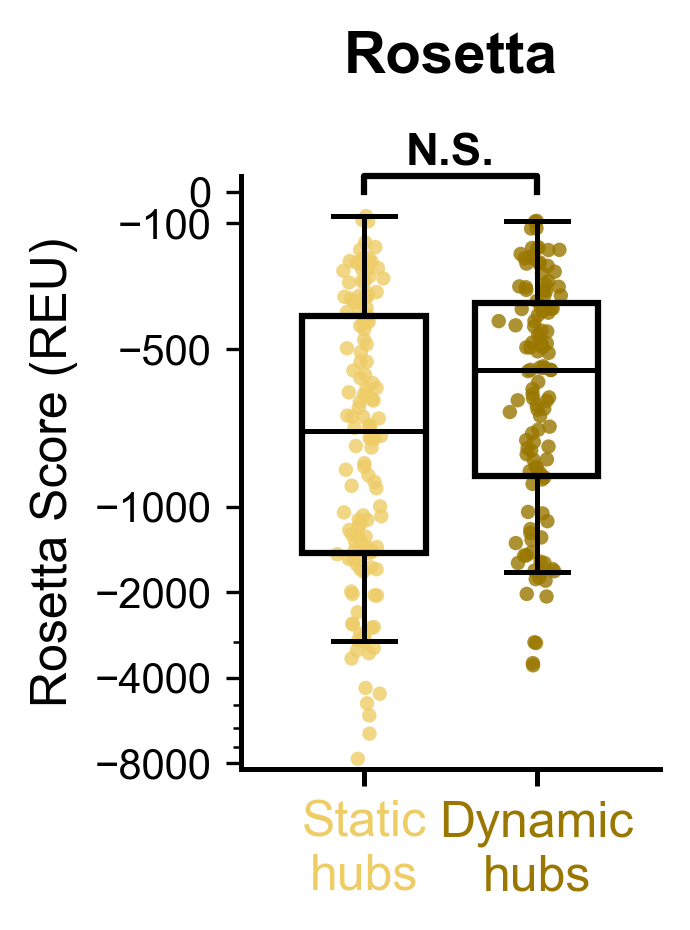

/tmp/ipykernel_1622/1352574327.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: 5.5.svg


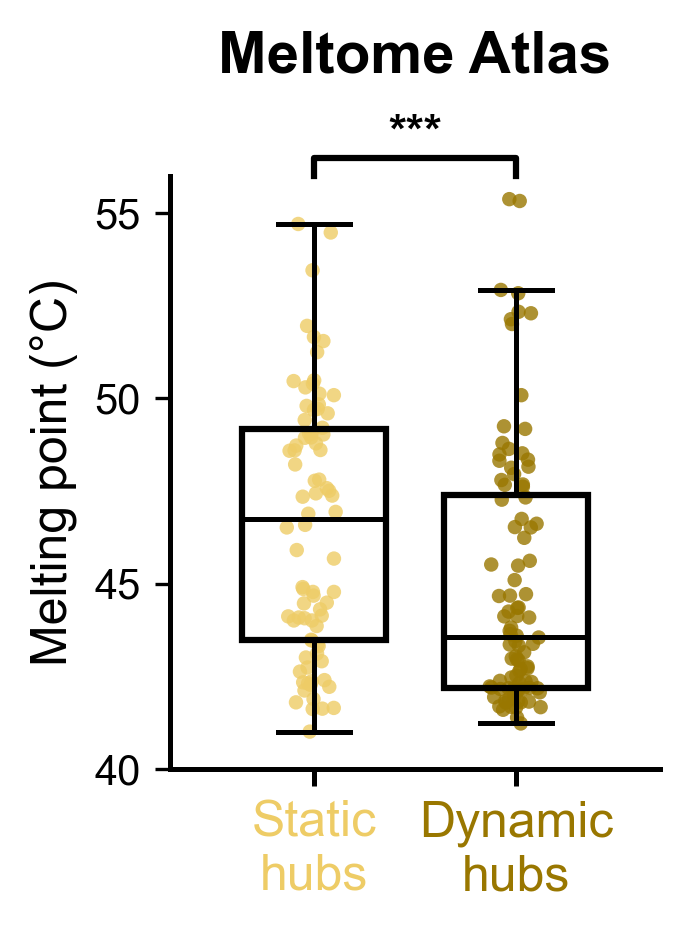

In [9]:
def draw_significance(ax, x1, x2, y, h, text):
    """
    Draws a straight bracket + text at EXACT y position and height h.
    - x1, x2 = x-coordinates of the two groups
    - y = vertical position of the bracket
    - h = height of the vertical bracket lines
    - text = significance stars
    """
    ax.plot([x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5, color="black", clip_on=False)
    
    ax.text((x1 + x2) / 2, y + h*1.1, text,
            ha="center", va="bottom",
            fontsize=11, fontweight="bold")

def base_box_scatter(ax, static_vals, dynamic_vals):
    positions = [1.0, 1.7]

    # === 1. Scatter ===
    for pos, vals, color in zip(
        positions,
        [static_vals, dynamic_vals],
        [MS_COLOR_LIGHT, MS_COLOR_DARK]
    ):
        x_jitter = pos + np.random.normal(0, 0.04, len(vals))
        ax.scatter(x_jitter, vals, s=12, alpha=0.8,
                   color=color, edgecolor="none", zorder=2)

    # === 2. Boxplot ===
    bp = ax.boxplot(
        [static_vals.values, dynamic_vals.values],
        positions=positions,
        labels=["Static", "Dynamic"],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
    )

    for box in bp["boxes"]:
        box.set_facecolor("none")
        box.set_edgecolor("black")
        box.set_linewidth(1.5)
        box.set_zorder(3)

    for element in ["whiskers", "caps", "medians"]:
        plt.setp(bp[element], color="black", linewidth=1.2)

    # === 3. X-axis labels ===
    ax.set_xticks(positions)
    ax.set_xticklabels(["Static\nhubs", "Dynamic\nhubs"],
                       fontsize=12)
    ax.tick_params(axis="x", length=4, width=1.2)

    labs = ax.get_xticklabels()
    labs[0].set_color(MS_COLOR_LIGHT)
    labs[1].set_color(MS_COLOR_DARK)

    #  === 4. Spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    return positions

figure_counter = 2
for stab_name, static_vals, dynamic_vals in groups_step4:

    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print("Skipping:", stab_name)
        continue

    fig, ax = plt.subplots(figsize=(2.4, 3.2))

    #  === 5. Base scatter+boxplot
    positions = base_box_scatter(ax, static_vals, dynamic_vals)
    ax.set_ylabel(stab_name, fontsize=11)
    ax.set_title("", fontsize=11)

    #  === 6. Metric-specific axis rules
    if "Rosetta" in stab_name:
        #ax.set_yscale("symlog", linthresh=10)
        ax.set_ylabel("Rosetta Score (REU)", fontsize=12)
        ax.set_title("Rosetta", fontweight='bold')
        ax.set_yscale("symlog", linthresh=1000)
        ax.set_ylim(-8400, 50)
        ax.set_yticks([-8000, -4000, -2000, -1000, -500, -100, 0])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = 0   
        bracket_h = 50 

    elif "Ghosh-Dill" in stab_name:
        ax.set_title("Ghosh & Dill", fontweight='bold')
        ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
        ax.set_yscale("symlog", linthresh=20)
        ax.set_ylim(-45, -4)
        ax.set_yticks([-10, -20, -30, -40])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = -3
        bracket_h = 0.5

    elif "Cagiada" in stab_name:
        ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
        ax.set_title("Cagiada et al.", fontweight='bold')
        ax.set_ylim(-40, 0)
        ax.set_yticks([0, -10, -20, -30, -40])
        bracket_y = 0.5
        bracket_h = 1.5

    elif "Meltome" in stab_name or "Tm" in stab_name:
        ax.set_ylabel("Melting point (°C)", fontsize=12)
        ax.set_title("Meltome Atlas", fontweight='bold')
        ax.set_ylim(40, 56)
        ax.set_yticks([40, 45, 50, 55])
        bracket_y = 56    
        bracket_h = 0.5
    

    #  === 7. Significance stars
    p_val = [r[2] for r in results if r[0] == stab_name][0]
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    draw_significance(ax, positions[0], positions[1], bracket_y, bracket_h, stars)

    #  === 8. AE-MS label below plot
    #trans = ax.get_xaxis_transform()
    #ax.plot([1.0, 1.7], [-0.24, -0.24], transform=trans,
    #        clip_on=False, color=MS_COLOR, lw=1.5)
    #ax.text(1.4, -0.26, "AE-MS", transform=trans,
    #        ha="center", va="top", fontsize=10,
    #        fontweight="bold", color=MS_COLOR)

    # === 9. Save
    plt.tight_layout()
    out = f"5.{figure_counter}.svg"
    plt.savefig(out, dpi=400, bbox_inches="tight")
    print("Saved:", out)

    figure_counter += 1
    plt.show()